# Continuation of an equilibrium solution

2025-11-04. Continue an ODE equilibrium solution using BifurcationKit, compare to DNS

## 0. Preliminaries

In [1]:
using LinearAlgebra, Polynomials, Plots, DelimitedFiles, BenchmarkTools, Revise
import BifurcationKit as BK

using CloudAtlas

#display("text/html", "<style>.container { width:100% !important; }</style>")

"""
    myreaddlm(filename, cc='%')

Read matrix or vector from a file, dropping comments marked with cc.
"""
function myreaddlm(filename; cc='%')
    X = readdlm(filename, comments=true, comment_char=cc)
    if size(X,2) == 1
        X = X[:,1]
    end
    X
end

sx, sy, sz, tx, tz = halfbox_symmetries()

pwd()

"c:\\Users\\cbalusek\\Desktop\\CloudAtlas\\notebooks"

## 1. Construct ODE model, find equilibrium solution.

This repeats some code from notebook `find-ode-eqb.ipynb`.

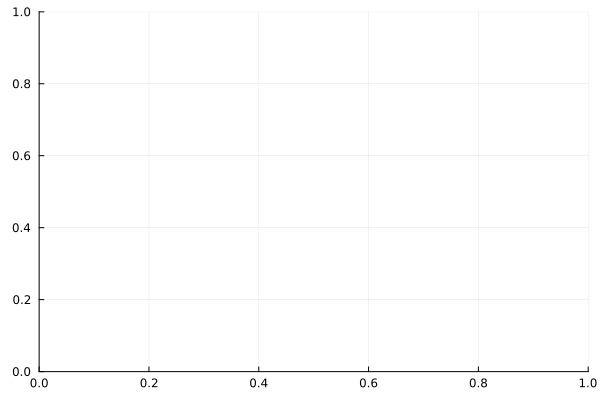

In [ ]:
plot()

In [11]:
α, γ = 1.45, 1.25                     # Fourier wavenumbers α, γ = 2π/Lx, 2π/Lz
J,K,L = 1,2,3  #1,2,3  #1,1,3                 # Bounds on Fourier modes (J,K) and wall-normal polynomials (L)
H = [sx*sy*sz, sz*tx*tz]            # Generators of the symmetric subspace of the Nagata eqb

model = ODEModel(α, γ, J, K, L, H)  # Construct ODE model by Galerkin projection 

@show m = length(model);            # dimension of ODE model

J,K,L,m == 1,2,3,27
(2J+1)(2K+1)(2L+1) + 1 == 106
Making matrices B,A1,A2,S3...
Making quadratic operator N...
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 
m = length(model) = 27


Load initial guesses for EQ1 (lower branch) and EQ2 (upper branch) from
files. These are computed by projecting DNS solutions onto the basis, using channelflow. 

In [ ]:
xguess = myreaddlm("data/xeq1projection-Re200-1-2-3-27d.asc") #data/xeq1projection-Re200-1-2-3-27d.asc

R = 200
#x = zeros(m)
@show norm(model.f(xguess, R)); #x, R

norm(model.f(xguess, R)) = 0.02183070260567872


Find the ODE representations of the lower and upper branch solutions.

In [ ]:
fr = x -> model.f(x,R)    # define function  f(x) = f(x,R)  for fixed R
Dfr = x -> model.Df(x,R)  # define function Df(x) = Df(x,R) for fixed R

@time xeq1, eq1success = hookstepsolve(fr, Dfr, xguess)

@show norm(fr(xeq1))/norm(xeq1);

  0.163206 seconds (88.35 k allocations: 10.959 MiB, 8.47% gc time, 85.63% compilation time)
norm(fr(xeq1)) / norm(xeq1) = 0.0002903499182265885


## 2. Continuation of eqbs with BifurcationKit



Compute bifurcation diagram from xeq1 solution.

In [ ]:
shear(xeq1, model)

1.2926825843845775

In [ ]:
myshear = x -> shear(x,model)
myshear(xeq1)

1.2926825843845775

In [ ]:
@show J, K, L, m, R

fp(x,p) = model.f(x,p[1])
prob1 = BK.BifurcationProblem(fp,
        xeq1,         # initial condition x0
        [Float64(R)], # set of parameters
        1;            # parameter index for continuation
        #record_from_solution = (x,p; k...) -> shear(x),
        plot_solution = (x,p; k...) -> myshear(x),
        record_from_solution = (x,p; k...) -> myshear(x),
    )

newtopts = BK.NewtonPar(1e-10, 25, false, BK.DefaultLS(), BK.DefaultEig(), false, 1.0, 0.01)
contopts = BK.ContinuationPar(p_min = 0., p_max = 400., n_inversion=20, dsmin=1e-12, dsmax=1.0, #Ask Gibson why dsmin was set to 1e-07
    max_steps = 600, newton_options = newtopts)

br1 = false
#try
    br1 = BK.continuation(prob1, BK.PALC(), contopts, bothside=true)  #Ask Gibson what this does besides throw errors
    plot!(br1)
#catch e
#    println(e)
#end


26-element Vector{Float64}:
 0.0001296593975235
 1.4043487048470003
 0.35128111874157664
 0.08707981527168025
 0.021266100843477753
 0.006930354607826154
 0.09763855800666318
 0.025026493111256803
 0.15721184493108428
 0.046609343976349214
 ⋮
 0.18655158983248227
 0.04757695019580662
 0.01774104880192161
 0.002864415047491175
 0.001993738156716504
 0.001251219006203309
 0.001678315947709994
 0.0011400525881876307
 0.004490301460574632

String: "Stopping continuation."

Compute bifurcation diagram from xeq2 solution. For some reason BifurcationKit doesn't go around the saddle-node bifurcation. I need to learn how to tune the algorithm.

Plot the ODE bifurcation diagram along with the DNS.

In [ ]:
ReD1 = [br1.param br1.x];

eq1ReD = myreaddlm("data/eq1ReD-DNS.asc", cc='#')
#@show minimum(eq1ReD[:,1]), minimum(ReD1[:,1])
print(minimum(eq1ReD[:,1]), " : ", minimum(ReD1[:,1]))
plot!(eq1ReD[:,1], eq1ReD[:,2], color=:black, label="eq1 DNS")
plot!(ReD1[:,1], ReD1[:,2], color=:blue, label="eq1 ODE, $J-$K-$L, $(m)d")
#plot!(ReD2[:,1], ReD2[:,2], color=:blue, label="")
plot!(xlabel="Re", ylabel="I", xlim=(150,300), ylim=(1,3))

In [162]:
using Suppressor
minDNS = false
parameters = []
minimums = []
guesses = []
AYErrors = []
matrix = []

Any[]

In [218]:
function DataTable(α, γ, center, posiN, negN, posiDeltaγ, negDeltaγ, J, K, L, H, Re, xGuess)
    @suppress begin
        try
            model = ODEModel(α, γ, J, K, L, H)  # Construct ODE model by Galerkin projection 
            fr = x -> model.f(x,Re)    # define function  f(x) = f(x,R)  for fixed R
            Dfr = x -> model.Df(x,Re)  # define function Df(x) = Df(x,R) for fixed R

            @time xeq1, eq1success = hookstepsolve(fr, Dfr, xGuess)

            ###@show norm(fr(xeq1))/norm(xeq1);
            ##################
            shear(xeq1, model)
            ##################
            myshear = x -> shear(x,model)
            myshear(xeq1)

            fp(x,p) = model.f(x,p[1])
            prob1 = BK.BifurcationProblem(fp,
                xeq1,         # initial condition x0
                [Float64(Re)], # set of parameters
                1;            # parameter index for continuation
                #record_from_solution = (x,p; k...) -> shear(x),
                plot_solution = (x,p; k...) -> myshear(x),
                record_from_solution = (x,p; k...) -> myshear(x),
            )

            newtopts = BK.NewtonPar(1e-10, 25, false, BK.DefaultLS(), BK.DefaultEig(), false, 1.0, 0.001)
            contopts = BK.ContinuationPar(p_min = 0., p_max = 400., n_inversion=20, dsmin=1e-12, dsmax=1.0, 
                max_steps = 600, newton_options = newtopts)

            br1 = BK.continuation(prob1, BK.PALC(), contopts, bothside=true)

            ###plot!(br1, legendfontsize=fs)
            ##################
            ReD1 = [br1.param br1.x];
            ##################
            mask = ReD1[:, 2] .> 1
            truncReD1 = ReD1[mask, :]
            if minimum(truncReD1[:,1]) > 1
                global matrix[center[2], center[1]] = minimum(truncReD1[:,1])
                if posiN != 0
                    DataTable_Helper(α, γ, [center[1], center[2] + 1], posiN, posiDeltaγ, J, K, L, H, Re, xeq1)
                end
                if negN != 0
                    DataTable_Helper(α, γ, [center[1], center[2] - 1], negN, -negDeltaγ, J, K, L, H, Re, xeq1)
                end
                return xeq1;
            else
                global matrix[center[2], center[1]] = 0
                if posiN != 0
                    DataTable_Helper(α, γ, [center[1], center[2] + 1], posiN, posiDeltaγ, J, K, L, H, Re, xeq1)
                end
                if negN != 0
                    DataTable_Helper(α, γ, [center[1], center[2] - 1], negN, -negDeltaγ, J, K, L, H, Re, xeq1)
                end
                return xeq1;
                push!(AYErrors, [α, γ, Re, xGuess])
            end
            #return [br1, ReD1, c, n, J, K, L, m, α, γ]
            #return [minimum(eq1ReD[:,1]), minimum(ReD1[:,1])]
            #push!(vectorTable, [minimum(eq1ReD[:,1]), minimum(ReD1[:,1])])
            #return vectorTable
        catch e
            #display(e)
            global matrix[center[2], center[1]] = 0
            if posiN != 0
                DataTable_Helper(α, γ, [center[1], center[2] + 1], posiN, posiDeltaγ, J, K, L, H, Re, xGuess)
            end
            if negN != 0
                DataTable_Helper(α, γ, [center[1], center[2] - 1], negN, -negDeltaγ, J, K, L, H, Re, xGuess)
            end
            return xGuess;
            push!(AYErrors, [α, γ, Re, xGuess, e])
        end
    end
end

DataTable (generic function with 1 method)

In [217]:
function DataTable_Helper(α, γ, center, n, deltaγ, J, K, L, H, Re, xGuess)
    @suppress begin
        if n == 0
            return
        else
            γ += deltaγ
            #display(α)
            #display(γ)
            try
                model = ODEModel(α, γ, J, K, L, H)  # Construct ODE model by Galerkin projection 
                fr = x -> model.f(x,Re)    # define function  f(x) = f(x,R)  for fixed R
                Dfr = x -> model.Df(x,Re)  # define function Df(x) = Df(x,R) for fixed R

                @time xeq1, eq1success = hookstepsolve(fr, Dfr, xGuess)
                ##################
                shear(xeq1, model)
                ##################
                myshear = x -> shear(x,model)
                myshear(xeq1)
                ####I = myshear(xeq1)
                ##################
                ###@show J, K, L, m, R

                fp(x,p) = model.f(x,p[1])
                prob1 = BK.BifurcationProblem(fp,
                    xeq1,         # initial condition x0
                    [Float64(Re)], # set of parameters
                    1;            # parameter index for continuation
                    #record_from_solution = (x,p; k...) -> shear(x),
                    plot_solution = (x,p; k...) -> myshear(x),
                    record_from_solution = (x,p; k...) -> myshear(x),
                )

                newtopts = BK.NewtonPar(1e-10, 25, false, BK.DefaultLS(), BK.DefaultEig(), false, 1.0, 0.001)
                contopts = BK.ContinuationPar(p_min = 0., p_max = 400., n_inversion=20, dsmin=1e-12, dsmax=1.0, 
                    max_steps = 600, newton_options = newtopts)

                br1 = BK.continuation(prob1, BK.PALC(), contopts, bothside=true)

                ###plot!(br1, legendfontsize=fs)
                ##################
                ReD1 = [br1.param br1.x];
                ##################
                mask = ReD1[:, 2] .> 1
                truncReD1 = ReD1[mask, :]
                if minimum(truncReD1[:,1]) > 1
                    global matrix[center[2], center[1]] = minimum(truncReD1[:,1])
                    if signbit(deltaγ)
                        DataTable_Helper(α, γ, [center[1], center[2] - 1], n - 1, deltaγ, J, K, L, H, Re, xeq1)
                    else
                        DataTable_Helper(α, γ, [center[1], center[2] + 1], n - 1, deltaγ, J, K, L, H, Re, xeq1)
                    end
                else
                    global matrix[center[2], center[1]] = 0
                    if signbit(deltaγ)
                        DataTable_Helper(α, γ, [center[1], center[2] - 1], n - 1, deltaγ, J, K, L, H, Re, xeq1)
                    else
                        DataTable_Helper(α, γ, [center[1], center[2] + 1], n - 1, deltaγ, J, K, L, H, Re, xeq1)
                    end
                    push!(AYErrors, [α, γ, Re, xGuess])
                end
                #return [br1, ReD1, c, n, J, K, L, m, α, γ]
                #return [minimum(eq1ReD[:,1]), minimum(ReD1[:,1])]
                #push!(vectorTable, [minimum(eq1ReD[:,1]), minimum(ReD1[:,1])])
                #return vectorTable
            catch e
                #display(e)
                global matrix[center[2], center[1]] = 0
                if signbit(deltaγ)
                    DataTable_Helper(α, γ, [center[1], center[2] - 1], n - 1, deltaγ, J, K, L, H, Re, xGuess)
                else
                    DataTable_Helper(α, γ, [center[1], center[2] + 1], n - 1, deltaγ, J, K, L, H, Re, xGuess)
                end
                push!(AYErrors, [α, γ, Re, xGuess, e])
            end
        end
    end
end

DataTable_Helper (generic function with 1 method)

In [87]:
function xGuessFinder(α, γ, αγRatio, n, posRan, negRan, J, K, L, H, Re, xGuess)
    @suppress begin
        minParam = [α, γ]
        model = ODEModel(α, γ, J, K, L, H)  # Construct ODE model by Galerkin projection 
        ##################
        fr = x -> model.f(x,Re)    # define function  f(x) = f(x,R)  for fixed R
        Dfr = x -> model.Df(x,Re)  # define function Df(x) = Df(x,R) for fixed R

        @time xeq1, eq1success = hookstepsolve(fr, Dfr, xGuess)
        ##################
        shear(xeq1, model)
        ##################
        myshear = x -> shear(x,model)
        myshear(xeq1)

        fp(x,p) = model.f(x,p[1])
        prob1 = BK.BifurcationProblem(fp,
            xeq1,         # initial condition x0
            [Float64(Re)], # set of parameters
            1;            # parameter index for continuation
            #record_from_solution = (x,p; k...) -> shear(x),
            plot_solution = (x,p; k...) -> myshear(x),
            record_from_solution = (x,p; k...) -> myshear(x),
        )

        newtopts = BK.NewtonPar(1e-10, 25, false, BK.DefaultLS(), BK.DefaultEig(), false, 1.0, 0.001)
        contopts = BK.ContinuationPar(p_min = 0., p_max = 400., n_inversion=20, dsmin=1e-12, dsmax=1.0, 
            max_steps = 600, newton_options = newtopts)

        br1 = BK.continuation(prob1, BK.PALC(), contopts, bothside=true)
        ReD1 = [br1.param br1.x];
        minRe = minimum(ReD1[:,1])
        xGuess = xeq1
        
        numOfTests = n
        posiRangeOfChange = posRan #1.5
        negRangeOfChange = negRan #0.85 #Do not set to 0
        delta = (posiRangeOfChange + negRangeOfChange)/numOfTests
        numOfNegTests = round(negRangeOfChange/delta)
        negDelta = negRangeOfChange/numOfNegTests
        negMin, negParam, negXGuess = xGuessFinder_Helper(α, γ, αγRatio, n, -negDelta, J, K, L, H, Re, xGuess, minRe, minParam)
        #push!(matrix, vcat([Re, initialA, initialY, true], xguess))

        numOfPosiTests = numOfTests - numOfNegTests
        posiDelta = posiRangeOfChange/numOfPosiTests
        posiMin, posiParam, posiXGuess = xGuessFinder_Helper(α, γ, αγRatio, n, posiDelta, J, K, L, H, Re, xGuess, minRe, minParam)
        
        if posiMin < negMin && posiMin < minRe
            return posiParam, posiXGuess
        elseif negMin < posiMin && negMin < minRe
            return negParam, negXGuess
        else 
            return minParam, xGuess
        end
    end
end

xGuessFinder (generic function with 1 method)

In [86]:
function xGuessFinder_Helper(α, γ, αγRatio, n, deltaα, J, K, L, H, Re, xGuess, minRe, minParam)
    @suppress begin
        if n == 0
            return minRe, minParam, xGuess
        else
            α += deltaα
            γ += deltaα * αγRatio
            try
                model = ODEModel(α, γ, J, K, L, H)  # Construct ODE model by Galerkin projection 
                ##################
                fr = x -> model.f(x,Re)    # define function  f(x) = f(x,R)  for fixed R
                Dfr = x -> model.Df(x,Re)  # define function Df(x) = Df(x,R) for fixed R

                @time xeq1, eq1success = hookstepsolve(fr, Dfr, xGuess)
                ##################
                shear(xeq1, model)
                ##################
                myshear = x -> shear(x,model)
                myshear(xeq1)

                fp(x,p) = model.f(x,p[1])
                prob1 = BK.BifurcationProblem(fp,
                    xeq1,         # initial condition x0
                    [Float64(Re)], # set of parameters
                    1;            # parameter index for continuation
                    #record_from_solution = (x,p; k...) -> shear(x),
                    plot_solution = (x,p; k...) -> myshear(x),
                    record_from_solution = (x,p; k...) -> myshear(x),
                )

                newtopts = BK.NewtonPar(1e-10, 25, false, BK.DefaultLS(), BK.DefaultEig(), false, 1.0, 0.001)
                contopts = BK.ContinuationPar(p_min = 0., p_max = 400., n_inversion=20, dsmin=1e-12, dsmax=1.0, 
                    max_steps = 600, newton_options = newtopts)

                br1 = BK.continuation(prob1, BK.PALC(), contopts, bothside=true)
                ##################
                ReD1 = [br1.param br1.x];
                ##################
                if minimum(ReD1[:,1]) > 1
                    if minimum(ReD1[:,1]) < minRe
                        return xGuessFinder_Helper(α, γ, αγRatio, n - 1, deltaα, J, K, L, H, Re, xeq1, minimum(ReD1[:,1]), [α,γ])
                    else
                        return xGuessFinder_Helper(α, γ, αγRatio, n - 1, deltaα, J, K, L, H, Re, xeq1, minRe, minParam)
                    end
                else
                    return xGuessFinder_Helper(α, γ, αγRatio, n - 1, deltaα, J, K, L, H, Re, xeq1, minRe, minParam)
                end
            catch e
                return xGuessFinder_Helper(α, γ, αγRatio, n - 1, deltaα, J, K, L, H, Re, xGuess, minRe, minParam)
            end
        end
    end
end

xGuessFinder_Helper (generic function with 1 method)

In [221]:
function contourMaker(α, αRange, γ, γRange, J, K, L, H, Re, xGuess, numOfTestsα)
    @suppress begin

        αγRatio = (γRange[2] - γRange[1])/(αRange[2] - αRange[1])
        numOfTestsγ = round(Int, numOfTestsα * αγRatio)

        minParam, minXGuess = xGuessFinder(α, γ, αγRatio, numOfTestsα, 
                                        min(αRange[2] - α, (γRange[2] - γ)/αγRatio), 
                                        min(α - αRange[1], (γ - γRange[1])/αγRatio), 
                                        J, K, L, H, Re, xGuess)
        α, γ = minParam

        global matrix = zeros(numOfTestsγ + 1, numOfTestsα + 1)
        minDNS = 163.5222

        negRangeOfChangeInα = (α - αRange[1])
        posiRangeOfChangeInα = (αRange[2] - α)
        
        deltaα = (negRangeOfChangeInα + posiRangeOfChangeInα) / numOfTestsα
        negαTests = round(negRangeOfChangeInα / deltaα)
        if negαTests != 0
            negαDelta = negRangeOfChangeInα / negαTests
        else 
            negαDelta = 0
        end

        negRangeOfChangeInγ = (γ - γRange[1])
        posiRangeOfChangeInγ = (γRange[2] - γ)

        deltaγ = (negRangeOfChangeInγ + posiRangeOfChangeInγ) / numOfTestsγ
        negγTests = round(negRangeOfChangeInγ / deltaγ)
        if negγTests != 0
            negγDelta = negRangeOfChangeInγ / negγTests
        else 
            negγDelta = 0
        end


        posiαTests = numOfTestsα - negαTests
        posiαDelta = posiRangeOfChangeInα / posiαTests

        posiγTests = numOfTestsγ - negγTests
        posiγDelta = posiRangeOfChangeInγ / posiγTests
        
        #=
        display(α)
        display(γ)
        display(numOfTestsα)
        display(numOfTestsγ)
        display("negRangeOfChangeInα : $negRangeOfChangeInα, deltaα : $deltaα, negαTests : $negαTests, negαDelta : $negαDelta")
        display("negRangeOfChangeInγ : $negRangeOfChangeInγ, deltaγ : $deltaγ, negγTests : $negγTests, negγDelta : $negγDelta")
        display("posiRangeOfChangeInα : $posiRangeOfChangeInα, deltaα : $deltaα, posiαTests : $posiαTests, posiαDelta : $posiαDelta")
        display("posiRangeOfChangeInγ : $posiRangeOfChangeInγ, deltaγ : $deltaγ, posiγTests : $posiγTests, posiγDelta : $posiγDelta")
        =#

        xGuess = minXGuess
        for i in 0:negαTests
            #DataTable(α, γ, center, posiN, negN, posiDeltaγ, negDeltaγ, J, K, L, H, Re, xGuess)
            xGuess = DataTable(α - i * negαDelta, γ, [round(Int, negαTests + 1 - i), round(Int, negγTests + 1)], posiγTests, negγTests, posiγDelta, negγDelta, J, K, L, H, Re, xGuess)
        end

        xGuess = minXGuess
        for i in 0:posiαTests
            xGuess = DataTable(α + i * posiαDelta, γ, [round(Int, negαTests + 1 + i), round(Int, negγTests + 1)], posiγTests, negγTests, posiγDelta, negγDelta, J, K, L, H, Re, xGuess)
        end

        #display(matrix)
        display(contour(αRange[1]:(αRange[2] - αRange[1])/numOfTestsα:αRange[2], γRange[1]:(γRange[2] - γRange[1])/numOfTestsγ:γRange[2], matrix, xlabel="α", ylabel="γ", lw=0, levels=200, fill = true, colormap =:jet))
        display(contour(reverse(collect(range((2*pi/αRange[1]), stop=(2*pi/(αRange[2])), length=size(matrix, 2)))), reverse(collect(range((2*pi/γRange[1]), stop=(2*pi/γRange[2]), length=size(matrix, 1)))), rot180(matrix), xlabel="Lx", ylabel="Lz", lw=0, levels=200, fill = true, colormap =:jet))
    end
end

contourMaker (generic function with 1 method)

26-element Vector{Float64}:
 3.016620026737255e-5
 0.27373061610189153
 0.06859283518011895
 0.017112040643565106
 0.004458228946574553
 0.0012441900143879236
 0.000426976502566269
 0.0007832057243413561
 0.00037721437314088723
 0.07507607750344451
 ⋮
 0.0008982627651885378
 0.00038664694090784695
 0.0037011774407316083
 0.0010300936659065623
 0.0004058992261176336
 0.0014033507876577806
 0.0004794970211063725
 0.0005583341422022467
 0.00042871649759143295

26-element Vector{Float64}:
 0.00015219827595900847
 0.6863195892010849
 0.17159222581235647
 0.04414491682449485
 0.010428672123231715
 0.003783261666888496
 0.002081460498643549
 0.011974875172062721
 0.003594846305788812
 0.0020204626136585964
 ⋮
 0.0708221840693178
 0.018218731245464116
 0.005114737533697858
 0.0020963191826934985
 0.010834702349265505
 0.0033199563171067586
 0.0020795851873527307
 0.012769815922607007
 0.00378352116470388

26-element Vector{Float64}:
  0.0002754751120490118
 15.960128482886029
  3.9899282247048045
  0.9974891773745892
  0.2497248365166768
  0.062178683946882016
  0.017598066845707562
  0.005710522762042689
  0.0046944216266117285
  0.005847855089431883
  ⋮
  0.004264782613569955
  0.010215312186125473
  0.0040790190284816855
  0.01603543423507289
  0.005262335131730582
  0.004798600178916927
  0.005880218272415381
  0.004195007567863982
  0.011719832654529775

26-element Vector{Float64}:
  0.00039222438771275637
 31.325383022666976
  7.831276135700992
  1.9573244343496914
  0.5175624959065248
  0.24534071970163918
  0.21960284340196892
  0.2452833140565955
  0.18774924895153763
  1.3808986535314087
  ⋮
  0.24872849625859364
  2.5544378711198545
  0.6598043378956998
  9.849743823061285
  2.6982999481271976
  7.5870785758585475
 98.55590706453032
 52.094051632026314
 12.87009138598502

26-element Vector{Float64}:
 3.016620026737255e-5
 0.27373061610189153
 0.06859283518011895
 0.017112040643565106
 0.004458228946574553
 0.0012441900143879236
 0.000426976502566269
 0.0007832057243413561
 0.00037721437314088723
 0.07507607750344451
 ⋮
 0.0008982627651885378
 0.00038664694090784695
 0.0037011774407316083
 0.0010300936659065623
 0.0004058992261176336
 0.0014033507876577806
 0.0004794970211063725
 0.0005583341422022467
 0.00042871649759143295

...

26-element Vector{Float64}:
  0.0002754751120490118
 15.960128482886029
  3.9899282247048045
  0.9974891773745892
  0.2497248365166768
  0.062178683946882016
  0.017598066845707562
  0.005710522762042689
  0.0046944216266117285
  0.005847855089431883
  ⋮
  0.004264782613569955
  0.010215312186125473
  0.0040790190284816855
  0.01603543423507289
  0.005262335131730582
  0.004798600178916927
  0.005880218272415381
  0.004195007567863982
  0.011719832654529775

26-element Vector{Float64}:
  0.00039222438771275637
 31.325383022666976
  7.831276135700992
  1.9573244343496914
  0.5175624959065248
  0.24534071970163918
  0.21960284340196892
  0.2452833140565955
  0.18774924895153763
  1.3808986535314087
  ⋮
  0.24872849625859364
  2.5544378711198545
  0.6598043378956998
  9.849743823061285
  2.6982999481271976
  7.5870785758585475
 98.55590706453032
 52.094051632026314
 12.87009138598502

26-element Vector{Float64}:
 9.152701426607762e-5
 1.0849954757103946
 0.27118464320610014
 0.06793587292186432
 0.01724567001813979
 0.004713011493814543
 0.0016636932057775382
 0.002061376287799835
 0.0014093498052104461
 0.004927107786040375
 ⋮
 0.009222637476371542
 0.0026869158490660182
 0.001309514289794473
 0.4872509150239172
 0.12214076839778831
 0.030865893895321496
 0.00805811688051913
 0.0024051195055834456
 0.0013188961520011746

26-element Vector{Float64}:
 0.00022757852200938036
 7.925489759428909
 1.981339003523411
 0.4948565689383457
 0.12541651703560175
 0.031215152776986037
 0.008917810819267425
 0.0042669066678718585
 0.016961757927829276
 0.005368063547688412
 ⋮
 0.0036605655985759915
 0.014953109913047604
 0.004853736557322191
 0.0041556461784653985
 0.0060030951486494104
 0.0035101611640132556
 0.041797302680351825
 0.011385403840301905
 0.004076876257947476

26-element Vector{Float64}:
  5.236180293983066e-5
 59.40367899698568
 14.850943162341093
  3.713266038529571
  0.9276609735814882
  0.23181618814478155
  0.06398596510502955
  0.013250295767626204
  0.0048052041454800295
  0.0011767020365485098
  ⋮
  0.0009352116452705904
  0.001141194175321317
  0.0008189007468557097
  0.0022267422453771334
  0.0008357964030966082
  0.001894443035793516
  0.0007796350999386221
  0.0042182909306583485
  0.0012802604598370854

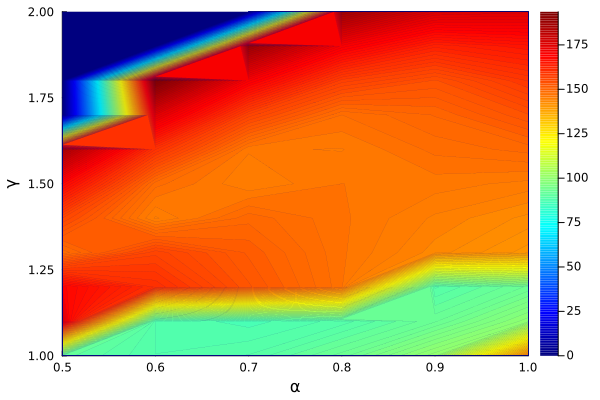

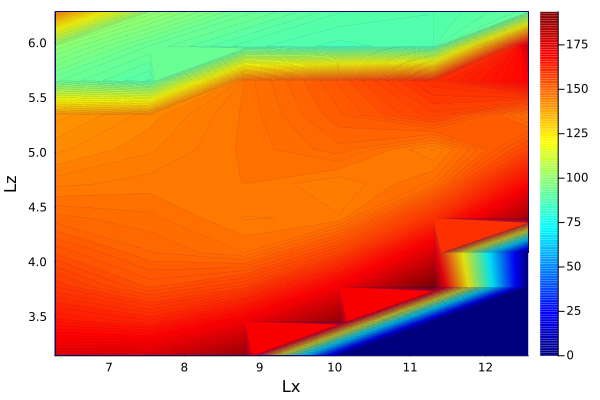

In [219]:
α, γ = 1.0, 2.0                     # Fourier wavenumbers α, γ = 2π/Lx, 2π/Lz
J,K,L = 1,2,3  #1,2,3  #1,1,3                 # Bounds on Fourier modes (J,K) and wall-normal polynomials (L)
H = [sx*sy*sz, sz*tx*tz]
Re = 200
matrix = []
AYErrors = []
xguess = myreaddlm("data/xeq1projection-Re200-1-2-3-27d.asc") #data/xeq1projection-Re200-1-2-3-27d.asc
contourMaker(1.0, [0.5, 1], 2.0, [1, 2], J, K, L, H, Re, xguess, 5)

In [222]:
display(AYErrors)

11-element Vector{Any}:
 Any[0.5000000000000001, 2.000000000000001, 200, [0.11263218798194582, -0.05216069355705289, 0.4061687373950616, -0.009860555518006825, -0.01742660427917869, 0.011315372205830038, 0.02364280654166424, -0.018186785811235968, -7.726805947137045e-5, -0.014336156971486783  …  -0.011261724568512918, -0.031091482966644872, -0.031718278869194504, -0.052143540530202405, -0.024870153483864947, 0.022341464730489504, 0.05044221182110552, -0.031311336319999696, -0.011835476067557152, -0.0026440405889016066], "Stopping continuation."]
 Any[0.5000000000000001, 1.9000000000000008, 200, [0.11263218798194582, -0.05216069355705289, 0.4061687373950616, -0.009860555518006825, -0.01742660427917869, 0.011315372205830038, 0.02364280654166424, -0.018186785811235968, -7.726805947137045e-5, -0.014336156971486783  …  -0.011261724568512918, -0.031091482966644872, -0.031718278869194504, -0.052143540530202405, -0.024870153483864947, 0.022341464730489504, 0.05044221182110552, -0.0313113363199